# OmniObject3D Selective Preprocessing

Downloads one category tar.gz at a time, samples 29 objects x 100 frames,
applies Kinect sensor noise to Blender depth, center-crops to 256x256,
and saves as PyTorch tensors matching the SUN RGB-D pipeline format.

**Est. pairs:** ~252K | **Runtime:** A100 recommended

## 1. Install & Imports

In [1]:
!pip install -q openxlab
!apt-get install -qq libopenexr-dev
!pip install -q OpenEXR Imath

import os, json, shutil, tarfile, random, subprocess
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter
from collections import defaultdict, Counter

print('Imports OK')
!df -h /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.5/314.5 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.4/239.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.1/953.1 kB 50.2 MB/s eta 0:0

## 2. Configuration

In [2]:
BASE_OUT_DIR     = '/content/sparse_omni_256'
TMP_DIR          = '/content/omni_tmp'
DRIVE_OUTPUT_TAR = '/content/drive/MyDrive/datasets/OmniObject3D_Pretrain_256.tar.gz'

OBJECTS_PER_CAT  = 30
FRAMES_PER_OBJ   = 100
TARGET_SIZE      = 256
MIN_DEPTH_VALID  = 0.005
NOISE_SEED       = 42
MIN_FREE_GB      = 20    # stop if VM disk drops below this

REPO             = 'omniobject3d/OmniObject3D-New'
# Exact path openxlab uses when downloading
OPENXLAB_PREFIX  = 'omniobject3d___OmniObject3D-New'

os.makedirs(BASE_OUT_DIR, exist_ok=True)
os.makedirs(TMP_DIR,      exist_ok=True)

print(f'Output: {BASE_OUT_DIR}')
print(f'Tmp:    {TMP_DIR}')

Output: /content/sparse_omni_256
Tmp:    /content/omni_tmp


## 3. Category List

In [3]:
INDOOR_CATS = [
    # furniture (8)
    'chair', 'sofa', 'stool', 'table', 'cabinet', 'house', 'kennel', 'tvstand',
    # kitchen (10)
    'bowl', 'bottle', 'cup', 'teapot', 'kettle', 'knife',
    'dish', 'box', 'red_wine_glass', 'picnic_basket',
    # appliances (4)
    'microwaveoven', 'ricecooker', 'fan', 'timer',
    # tech / office (7)
    'keyboard', 'mouse', 'pad', 'remote_control',
    'projector', 'calculator', 'speaker',
    # clothing / accessories (9)
    'backpack', 'handbag', 'hat', 'helmet', 'shoe',
    'suitcase', 'umbrella', 'gloves', 'belt',
    # personal (10)
    'wallet', 'watch', 'tooth_brush', 'tooth_paste',
    'shampoo', 'soap', 'hair_dryer', 'hand_cream',
    'lipstick', 'laundry_detergent',
    # home (10)
    'book', 'clock', 'pillow', 'tissue', 'vase',
    'candle', 'dustbin', 'flower_pot', 'plant', 'light',
    # tools / sport (7)
    'hammer', 'scissor', 'tape_measure', 'dumbbell',
    'ball', 'kite', 'frisbee',
    # toys (6)
    'doll', 'teddy_bear', 'toy_car', 'rubik_cube', 'toy_boat', 'toy_plane',
    # food (13)
    'apple', 'banana', 'orange', 'egg', 'bread', 'cake',
    'broccoli', 'carrot', 'tomato', 'lemon', 'pineapple',
    'potato', 'mushroom',
    # misc (6)
    'eraser', 'chess', 'medicine_bottle', 'power_strip',
    'fire_extinguisher', 'garage_kit',
]

assert len(set(INDOOR_CATS)) == len(INDOOR_CATS) == 90
print(f'{len(INDOOR_CATS)} categories, {len(set(INDOOR_CATS))} unique')
print(f'90 x 30 x 100 = {90*30*100:,} pairs')

cat_to_idx = {cat: idx for idx, cat in enumerate(INDOOR_CATS)}

print(f'Categories:     {len(INDOOR_CATS)}')
print(f'Max objects:    {OBJECTS_PER_CAT} per category')
print(f'Frames/object:  {FRAMES_PER_OBJ}')
print(f'Est. pairs:     ~{len(INDOOR_CATS) * OBJECTS_PER_CAT * FRAMES_PER_OBJ:,}')

90 categories, 90 unique
87 x 29 x 100 = 261,000 pairs
Categories:     90
Max objects:    30 per category
Frames/object:  100
Est. pairs:     ~270,000


## 4. Mount Drive + Login

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['OPENXLAB_AK'] = 'bmyqk5wpbaxl6x1vkzq9'
os.environ['OPENXLAB_SK'] = 'nl7kq9palyr6j3pwxolden7ezq4dwjmbgdm81yeo'

# Verify connection
ret = os.system('openxlab dataset info --dataset-repo omniobject3d/OmniObject3D-New > /dev/null 2>&1')
print(f'OpenDataLab connection: {"OK" if ret == 0 else "FAILED"}')

Mounted at /content/drive
OpenDataLab connection: OK


## 5. Kinect Noise Simulation

In [5]:
def simulate_kinect_depth(depth_clean, rgb=None, rng=None):
    if rng is None:
        rng = np.random.RandomState()

    depth = depth_clean.copy().astype(np.float32)
    H, W  = depth.shape

    # Zero out Blender background (rendered at ~65504 = float16 infinity sentinel)
    depth[depth > 100.0] = 0.0

    # Clip to Kinect sensor range (0.3m - 5.0m)
    depth[(depth < 0.3) | (depth > 5.0)] = 0.0
    valid = depth > 0
    depth = np.round(depth * 1000.0) / 1000.0
    sigma = np.zeros_like(depth)
    sigma[valid] = 0.0012 + 0.0019 * np.maximum(depth[valid] - 0.4, 0) ** 2
    noise = rng.normal(0, 1, (H, W)).astype(np.float32) * sigma
    depth[valid] += noise[valid]
    dy = np.abs(np.diff(depth, axis=0, prepend=depth[:1]))
    dx = np.abs(np.diff(depth, axis=1, prepend=depth[:, :1]))
    blend = np.clip((dy + dx) / 0.05 * 0.4, 0, 0.4)
    depth_blur = gaussian_filter(depth, sigma=0.8)
    depth = depth * (1 - blend) + depth_blur * blend
    hard_edge = (dy + dx) > 0.1
    depth[hard_edge & (rng.random((H, W)) < 0.6)] = 0.0
    if rgb is not None:
        gray = rgb.mean(axis=2).astype(np.float32)
        problem = (gray > 230) | (gray < 20)
        depth[problem & (rng.random((H, W)) < 0.75)] = 0.0
    depth[rng.random((H, W)) < 0.005] = 0.0
    if rng.random() < 0.05:
        ph, pw = rng.randint(20, 60), rng.randint(20, 60)
        py = rng.randint(0, max(1, H - ph))
        px = rng.randint(0, max(1, W - pw))
        depth[py:py+ph, px:px+pw] = 0.0
    return np.clip(depth, 0.0, 5.0)

print('Kinect noise simulator loaded')

Kinect noise simulator loaded


## 6. Frame Processing Helpers

In [6]:
def load_exr_depth(path):
    try:
        import OpenEXR, Imath
        f   = OpenEXR.InputFile(str(path))
        dw  = f.header()['dataWindow']
        W   = dw.max.x - dw.min.x + 1
        H   = dw.max.y - dw.min.y + 1
        chs = list(f.header()['channels'].keys())
        ch  = 'Z' if 'Z' in chs else chs[0]
        pt  = Imath.PixelType(Imath.PixelType.FLOAT)
        return np.frombuffer(f.channel(ch, pt), dtype=np.float32).reshape(H, W)
    except Exception:
        import imageio
        d = imageio.imread(str(path), format='exr')
        return (d[:,:,0] if d.ndim == 3 else d).astype(np.float32)


def center_crop_square(img):
    w, h = img.size
    s    = min(w, h)
    return img.crop(((w-s)//2, (h-s)//2, (w-s)//2+s, (h-s)//2+s))


def process_frame(rgb_path, depth_path, rng):
    try:
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_arr = np.array(rgb_img)
        ext = Path(depth_path).suffix.lower()
        if ext == '.exr':
            depth = load_exr_depth(depth_path).copy()
        else:
            d     = Image.open(depth_path)
            depth = np.array(d, dtype=np.float32)
            if depth.max() > 100:
                depth = depth / 1000.0
        if depth.shape[:2] != (rgb_img.height, rgb_img.width):
            d_pil = Image.fromarray(depth).resize(
                (rgb_img.width, rgb_img.height), Image.Resampling.NEAREST)
            depth = np.array(d_pil, dtype=np.float32)
        depth = simulate_kinect_depth(depth, rgb=rgb_arr, rng=rng)
        if (depth > 0).mean() < MIN_DEPTH_VALID:
            return None, None
        rgb_c = center_crop_square(rgb_img)
        rgb_c = rgb_c.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.LANCZOS)
        d_pil = Image.fromarray(depth)
        d_pil = center_crop_square(d_pil)
        d_pil = d_pil.resize((TARGET_SIZE, TARGET_SIZE), Image.Resampling.NEAREST)
        depth_c  = np.array(d_pil, dtype=np.float32)
        depth_mm = np.clip(depth_c * 1000.0, 0, 65535).astype(np.uint16)
        if (depth_mm > 0).mean() < MIN_DEPTH_VALID:
            return None, None
        rgb_t   = torch.from_numpy(np.array(rgb_c, dtype=np.uint8)).permute(2, 0, 1)
        depth_t = torch.from_numpy(depth_mm).unsqueeze(0)
        return rgb_t, depth_t
    except Exception as e:
        print(f'process_frame error: {type(e).__name__}: {e}')
        return None, None


def free_gb():
    return shutil.disk_usage('/content').free / 1e9


print('Processing helpers loaded')

Processing helpers loaded


## 7. Download + Process Loop

In [7]:
# cat = 'sofa'
# ret = os.system(
#     f'openxlab dataset download --dataset-repo {REPO} '
#     f'--source-path /raw/blender_renders/{cat}.tar.gz '
#     f'--target-path {TMP_DIR} 2>/dev/null'
# )
# print(f'Download rc: {ret}')

# tar = TAR_BASE / f'{cat}.tar.gz'
# print(f'Tar exists: {tar.exists()}, size: {tar.stat().st_size / 1e6:.1f} MB')

In [8]:
# import tarfile, random
# import OpenEXR, Imath
# import numpy as np

# extract_dir = Path(TMP_DIR) / f'ex_{cat}'
# with tarfile.open(tar) as t:
#     t.extractall(extract_dir)
# tar.unlink()

# # Count objects (subdirectories = one per object)
# obj_dirs = [d for d in extract_dir.iterdir() if d.is_dir()]
# print(f'Objects found: {len(obj_dirs)}')

# exr_files = list(extract_dir.rglob('*_depth.exr'))
# print(f'Total EXR files: {len(exr_files)} (expect {len(obj_dirs)*100})')

# exr = random.choice(exr_files)
# f = OpenEXR.InputFile(str(exr))
# dw = f.header()['dataWindow']
# depth = np.frombuffer(
#     f.channel('R', Imath.PixelType(Imath.PixelType.FLOAT)),
#     dtype=np.float32
# ).reshape(dw.max.y - dw.min.y + 1, dw.max.x - dw.min.x + 1).copy()

# depth[depth > 100.0] = 0.0
# valid = depth[depth > 0]
# print(f'Depth range: {valid.min():.2f}m - {valid.max():.2f}m')
# print(f'Valid pixels: {len(valid)} / {depth.size} ({100*len(valid)/depth.size:.1f}%)')

In [9]:
stats = defaultdict(int)

# INDOOR_CATS = ['sofa']
# cat_to_idx  = {cat: idx for idx, cat in enumerate(INDOOR_CATS)}

# ── Restore from Drive checkpoint if local is empty ───────────────────
DRIVE_CHECKPOINT = '/content/drive/MyDrive/datasets/sparse_omni_256_raw'
if os.path.isdir(DRIVE_CHECKPOINT) and not any(
    (Path(BASE_OUT_DIR) / c).exists() for c in INDOOR_CATS
):
    drive_cats = [c for c in INDOOR_CATS
                  if (Path(DRIVE_CHECKPOINT) / c).exists()]
    print(f'Restoring {len(drive_cats)} categories from Drive...')
    for ri, rc in enumerate(drive_cats):
        print(f'  [{ri+1}/{len(drive_cats)}] {rc}', end='\r')
        shutil.copytree(Path(DRIVE_CHECKPOINT) / rc,
                        Path(BASE_OUT_DIR) / rc, dirs_exist_ok=True)
    print(f'\nRestore complete: {len(drive_cats)} categories.')

for cat_idx, cat_name in enumerate(tqdm(INDOOR_CATS, desc='Categories')):

    # ── Disk guard ────────────────────────────────────────────────────────
    gb_free = free_gb()
    if gb_free < MIN_FREE_GB:
        print(f'\nDisk low ({gb_free:.1f}GB free) — stopping early at {cat_name}')
        break

    cat_out = Path(BASE_OUT_DIR) / cat_name

    # ── Resume: skip if already processed (marker file written on success)
    done_marker = cat_out / '.done'
    if done_marker.exists():
        stats['cats_resumed'] += 1
        continue

    # ── Clean partial data from a prior interrupted run ───────────────
    if cat_out.exists():
        shutil.rmtree(cat_out)
    cat_out.mkdir(parents=True, exist_ok=True)

    # ── Exact download path openxlab uses ─────────────────────────────────
    tar_path = (
        Path(TMP_DIR) / OPENXLAB_PREFIX /
        'raw' / 'blender_renders' / f'{cat_name}.tar.gz'
    )

    # ── Download ──────────────────────────────────────────────────────────
    ret = os.system(
        f'openxlab dataset download '
        f'--dataset-repo {REPO} '
        f'--source-path /raw/blender_renders/{cat_name}.tar.gz '
        f'--target-path {TMP_DIR} 2>/dev/null'
    )

    if ret != 0 or not tar_path.exists():
        # Fallback: search anywhere under TMP_DIR
        found = list(Path(TMP_DIR).rglob(f'{cat_name}.tar.gz'))
        if found:
            tar_path = found[0]
        else:
            print(f'  Download failed or not found: {cat_name}')
            stats['download_failed'] += 1
            continue

    # ── Extract ───────────────────────────────────────────────────────────
    extract_dir = Path(TMP_DIR) / f'ex_{cat_name}'
    extract_dir.mkdir(parents=True, exist_ok=True)

    try:
        with tarfile.open(tar_path, 'r:gz') as tar:
            tar.extractall(extract_dir, filter='data')
    except Exception as e:
        print(f'  Extract failed: {cat_name}: {e}')
        stats['extract_failed'] += 1
        tar_path.unlink(missing_ok=True)
        shutil.rmtree(extract_dir, ignore_errors=True)
        continue
    finally:
        tar_path.unlink(missing_ok=True)  # free disk immediately after extract

    # ── Find object dirs ──────────────────────────────────────────────────
    # Structure: extract_dir/<cat_name>/<obj_id>/render/images/ + depths/
    obj_dirs = []
    for render_dir in extract_dir.rglob('render'):
        if (render_dir / 'images').exists() and (render_dir / 'depths').exists():
            obj_dirs.append(render_dir.parent)
    obj_dirs = sorted(set(obj_dirs))

    if not obj_dirs:
        print(f'  No valid objects found: {cat_name}')
        stats['no_objects'] += 1
        shutil.rmtree(extract_dir, ignore_errors=True)
        continue

    # Sample up to OBJECTS_PER_CAT randomly
    random.seed(NOISE_SEED + cat_idx)  # deterministic per-category, resume-safe
    sampled = random.sample(obj_dirs, min(OBJECTS_PER_CAT, len(obj_dirs)))
    stats['cats_processed'] += 1

    # ── Process frames ────────────────────────────────────────────────────
    for obj_dir in tqdm(sampled, desc=cat_name, leave=False):
        obj_id = obj_dir.name

        rgb_files   = sorted((obj_dir / 'render' / 'images').glob('*.*'))
        depth_files = sorted((obj_dir / 'render' / 'depths').glob('*.*'))

        if not rgb_files or len(rgb_files) != len(depth_files):
            stats['invalid_obj'] += 1
            continue

        n       = min(len(rgb_files), len(depth_files))
        indices = np.linspace(0, n - 1, FRAMES_PER_OBJ, dtype=int)

        obj_hash = int(__import__('hashlib').md5(obj_id.encode()).hexdigest()[:8], 16) % 10000
        obj_seed = NOISE_SEED + cat_to_idx[cat_name] * 10000 + obj_hash
        rng      = np.random.RandomState(obj_seed % (2**31))

        for out_idx, frame_idx in enumerate(indices):
            rgb_t, depth_t = process_frame(
                rgb_files[frame_idx], depth_files[frame_idx], rng
            )
            if rgb_t is None:
                stats['frame_invalid'] += 1
                continue
            base = str(cat_out / f'{obj_id}_f{out_idx:03d}')
            torch.save(rgb_t,   base + '_rgb.pt')
            torch.save(depth_t, base + '_depth.pt')
            stats['saved'] += 1

    # ── Cleanup extracted folder ──────────────────────────────────────────
    shutil.rmtree(extract_dir, ignore_errors=True)

    # ── Incremental Drive checkpoint, then mark complete ────────────────
    print(f'  Checkpointing {cat_name} to Drive...', end='')
    drive_cat = Path(DRIVE_CHECKPOINT) / cat_name
    drive_cat.mkdir(parents=True, exist_ok=True)
    shutil.copytree(cat_out, drive_cat, dirs_exist_ok=True)
    done_marker.touch()
    shutil.copy2(done_marker, drive_cat / '.done')
    print(' done.')

    # Disk check every 5 categories
    if cat_idx % 5 == 0:
        print(f'  [{cat_idx+1}/{len(INDOOR_CATS)}] {cat_name}'
              f' — saved: {stats["saved"]:,}'
              f' — disk free: {free_gb():.1f}GB')

print()
print('=== Stats ===')
for k, v in sorted(stats.items()):
    print(f'  {k:<25} {v:>6,}')

print('Full checkpoint on Drive is already up-to-date.')

Categories:   0%|          | 0/90 [00:00<?, ?it/s]

chair:   0%|          | 0/29 [00:00<?, ?it/s]

  [1/90] chair — saved: 2,900 — disk free: 218.7GB


sofa:   0%|          | 0/14 [00:00<?, ?it/s]

stool:   0%|          | 0/11 [00:00<?, ?it/s]

...

medicine_bottle:   0%|          | 0/30 [00:00<?, ?it/s]

power_strip:   0%|          | 0/30 [00:00<?, ?it/s]

fire_extinguisher:   0%|          | 0/19 [00:00<?, ?it/s]

garage_kit:   0%|          | 0/30 [00:00<?, ?it/s]


=== Stats ===
  cats_processed                90
  frame_invalid                794
  saved                     204,606
Saving checkpoint to Drive...
Checkpoint saved.


## 8. Disk Check

In [10]:
!df -h /content
!du -sh {BASE_OUT_DIR}

Filesystem      Size  Used Avail Use% Mounted on
overlay         226G  133G   94G  59% /
65G	/content/sparse_omni_256


## 8b. Object-Level Train/Val Split

Splits by **object ID** so all frames of a 3D object go entirely into
either the train or val set. This prevents data leakage between splits.
Stratified by category to ensure every class appears in both splits.

In [ ]:
import re
import hashlib
from collections import defaultdict

SPLIT_SEED = 42
VAL_FRACTION = 0.1

# ── Remove .done markers (used by processing loop for resume) ─────
for cat_name in INDOOR_CATS:
    marker = Path(BASE_OUT_DIR) / cat_name / '.done'
    if marker.exists():
        marker.unlink()

# ── Discover all processed samples and group by object ID ─────────
obj_to_files = defaultdict(list)  # full_obj_id -> [(rgb_path, depth_path)]
obj_to_cat = {}                   # full_obj_id -> cat_name

for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / cat_name
    if not cat_dir.exists():
        continue
    for rgb_file in sorted(cat_dir.glob('*_rgb.pt')):
        depth_file = Path(str(rgb_file).replace('_rgb.pt', '_depth.pt'))
        if not depth_file.exists():
            continue
        # Extract object ID: strip _f<digits> frame suffix
        stem = rgb_file.stem.replace('_rgb', '')
        match = re.match(r'^(.+)_f\d+$', stem)
        obj_id = match.group(1) if match else stem
        full_obj_id = f'{cat_name}/{obj_id}'
        obj_to_files[full_obj_id].append((rgb_file, depth_file))
        obj_to_cat[full_obj_id] = cat_name

print(f'Total objects: {len(obj_to_files)}')
print(f'Total frame pairs: {sum(len(v) for v in obj_to_files.values()):,}')

# ── Stratified object-level split ─────────────────────────────────
rng = np.random.RandomState(SPLIT_SEED)
cat_to_objs = defaultdict(list)
for full_obj_id, cat_name in obj_to_cat.items():
    cat_to_objs[cat_name].append(full_obj_id)

train_dir = Path(BASE_OUT_DIR) / 'train'
val_dir   = Path(BASE_OUT_DIR) / 'val'

for cat_name in INDOOR_CATS:
    (train_dir / cat_name).mkdir(parents=True, exist_ok=True)
    (val_dir / cat_name).mkdir(parents=True, exist_ok=True)

train_count, val_count = 0, 0
for cat_name in sorted(cat_to_objs.keys()):
    obj_ids = sorted(cat_to_objs[cat_name])
    rng.shuffle(obj_ids)
    cut = max(1, int(len(obj_ids) * (1 - VAL_FRACTION)))

    for full_obj_id in obj_ids[:cut]:
        cn = obj_to_cat[full_obj_id]
        for rgb_file, depth_file in obj_to_files[full_obj_id]:
            shutil.move(str(rgb_file), str(train_dir / cn / rgb_file.name))
            shutil.move(str(depth_file), str(train_dir / cn / depth_file.name))
            train_count += 1

    for full_obj_id in obj_ids[cut:]:
        cn = obj_to_cat[full_obj_id]
        for rgb_file, depth_file in obj_to_files[full_obj_id]:
            shutil.move(str(rgb_file), str(val_dir / cn / rgb_file.name))
            shutil.move(str(depth_file), str(val_dir / cn / depth_file.name))
            val_count += 1

# Clean up empty category dirs at root level
for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / cat_name
    if cat_dir.exists() and not list(cat_dir.iterdir()):
        cat_dir.rmdir()

# Warn about categories with no val data
for cat_name in sorted(cat_to_objs.keys()):
    n_objs = len(cat_to_objs[cat_name])
    if n_objs <= 1:
        print(f'  WARNING: {cat_name} has only {n_objs} object(s) — no val samples')

print(f'\nSplit complete!')
print(f'  Train: {train_count:,} frame pairs')
print(f'  Val:   {val_count:,} frame pairs')
print(f'  Val fraction: {val_count / (train_count + val_count):.1%}')

## 9. Normalization Stats

Computed by streaming over per-sample files — no full RAM load needed.

In [11]:
print('Scanning per-sample files from train split...')

all_rgb_paths, all_depth_paths, all_labels = [], [], []
train_split_dir = Path(BASE_OUT_DIR) / 'train'

for cat_name in INDOOR_CATS:
    cat_dir = train_split_dir / cat_name
    if not cat_dir.exists():
        continue
    label_idx = cat_to_idx[cat_name]
    for rf in sorted(cat_dir.glob('*_rgb.pt')):
        df = Path(str(rf).replace('_rgb.pt', '_depth.pt'))
        if df.exists():
            all_rgb_paths.append(rf)
            all_depth_paths.append(df)
            all_labels.append(label_idx)

N = len(all_rgb_paths)
print(f'Train samples: {N:,}')
print(f'Categories with data: {len(set(all_labels))}')

# Reservoir-sample 5K frames to estimate mean/std without loading all data
import random as pyrandom
pyrandom.seed(42)
sample_size = min(N, 5000)
sample_idx  = sorted(pyrandom.sample(range(N), sample_size))

rgb_acc, depth_acc = [], []
for i in tqdm(sample_idx, desc='Sampling for stats'):
    rgb_t_i = torch.load(all_rgb_paths[i],   weights_only=True).float() / 255.0
    depth_t_i = torch.load(all_depth_paths[i], weights_only=True).to(torch.int32)  # uint16 → int32 for comparison
    valid = depth_t_i[depth_t_i > 0].float() / 1000.0  # mm → meters
    rgb_acc.append(rgb_t_i)
    if len(valid) > 0:
        depth_acc.append(valid)

rgb_stack  = torch.stack(rgb_acc)   # [S, 3, 256, 256]
rgb_mean   = rgb_stack.mean(dim=(0, 2, 3)).tolist()
rgb_std    = rgb_stack.std(dim=(0, 2, 3)).tolist()
depth_all  = torch.cat(depth_acc)
depth_mean = [depth_all.mean().item()]
depth_std  = [depth_all.std().item()]

stats_dict = {
    'rgb_mean':    rgb_mean,
    'rgb_std':     rgb_std,
    'depth_mean':  depth_mean,
    'depth_std':   depth_std,
    'n_train_samples': N,
    'n_classes':   len(INDOOR_CATS),
    'target_size': TARGET_SIZE,
}

with open(os.path.join(BASE_OUT_DIR, 'norm_stats.json'), 'w') as f:
    json.dump(stats_dict, f, indent=2)

print(f'RGB mean:   {[round(x,4) for x in rgb_mean]}')
print(f'RGB std:    {[round(x,4) for x in rgb_std]}')
print(f'Depth mean: {[round(x,4) for x in depth_mean]}')
print(f'Depth std:  {[round(x,4) for x in depth_std]}')


Scanning per-sample files...
Total samples: 204,606
Categories with data: 90


Sampling for stats:   0%|          | 0/5000 [00:00<?, ?it/s]

RGB mean:   [0.0855, 0.0817, 0.0641]
RGB std:    [0.2065, 0.1989, 0.1715]
Depth mean: [3.5551]
Depth std:  [0.3629]


## 10. Metadata

In [12]:
from collections import Counter

with open(os.path.join(BASE_OUT_DIR, 'class_names.txt'), 'w') as f:
    for i, name in enumerate(INDOOR_CATS):
        f.write(f'{i}: {name}\n')

# Count from both splits
all_labels_both = []
for split in ['train', 'val']:
    split_dir = Path(BASE_OUT_DIR) / split
    for cat_name in INDOOR_CATS:
        cat_dir = split_dir / cat_name
        if not cat_dir.exists():
            continue
        label_idx = cat_to_idx[cat_name]
        n_files = len(list(cat_dir.glob('*_rgb.pt')))
        all_labels_both.extend([label_idx] * n_files)

N_total = len(all_labels_both)
dist = Counter(all_labels_both)

with open(os.path.join(BASE_OUT_DIR, 'dataset_info.txt'), 'w') as f:
    f.write('OmniObject3D Indoor Preprocessed Dataset\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Total samples:    {N_total:,}\n')
    f.write(f'Train samples:    {train_count:,}\n')
    f.write(f'Val samples:      {val_count:,}\n')
    f.write(f'Categories:       {len(INDOOR_CATS)}\n')
    f.write(f'Objects/category: up to {OBJECTS_PER_CAT}\n')
    f.write(f'Frames/object:    {FRAMES_PER_OBJ}\n')
    f.write(f'Tensor size:      {TARGET_SIZE}x{TARGET_SIZE}\n\n')
    f.write('Directory structure:\n')
    f.write('  train/<cat>/<obj_id>_f<N>_rgb.pt   uint8  [3, 256, 256]\n')
    f.write('  train/<cat>/<obj_id>_f<N>_depth.pt uint16 [1, 256, 256] (mm, 0=missing)\n')
    f.write('  val/<cat>/...\n\n')
    f.write('Class distribution (total):\n')
    for i, name in enumerate(INDOOR_CATS):
        f.write(f'  {i:2d}  {name:<35}  {dist.get(i, 0):>5,}\n')

print('Metadata written')
for i, name in enumerate(INDOOR_CATS):
    if dist.get(i, 0) > 0:
        print(f'  {name:<30} {dist.get(i,0):>5,}')


Metadata written
  chair                          2,900
  sofa                           1,400
  stool                          1,100
  table                          2,400
  cabinet                          700
  house                          3,000
  kennel                           400
  tvstand                          300
  bowl                           1,200
  bottle                         2,600
  cup                            3,000
  teapot                         2,900
  kettle                         1,200
  knife                          2,848
  dish                           1,800
  box                            3,000
  red_wine_glass                 2,100
  picnic_basket                  1,100
  microwaveoven                    800
  ricecooker                       900
  fan                            1,491
  timer                          2,200
  keyboard                       1,581
  mouse                          3,000
  pad                            2,108
  remote

## 11. Spot Check

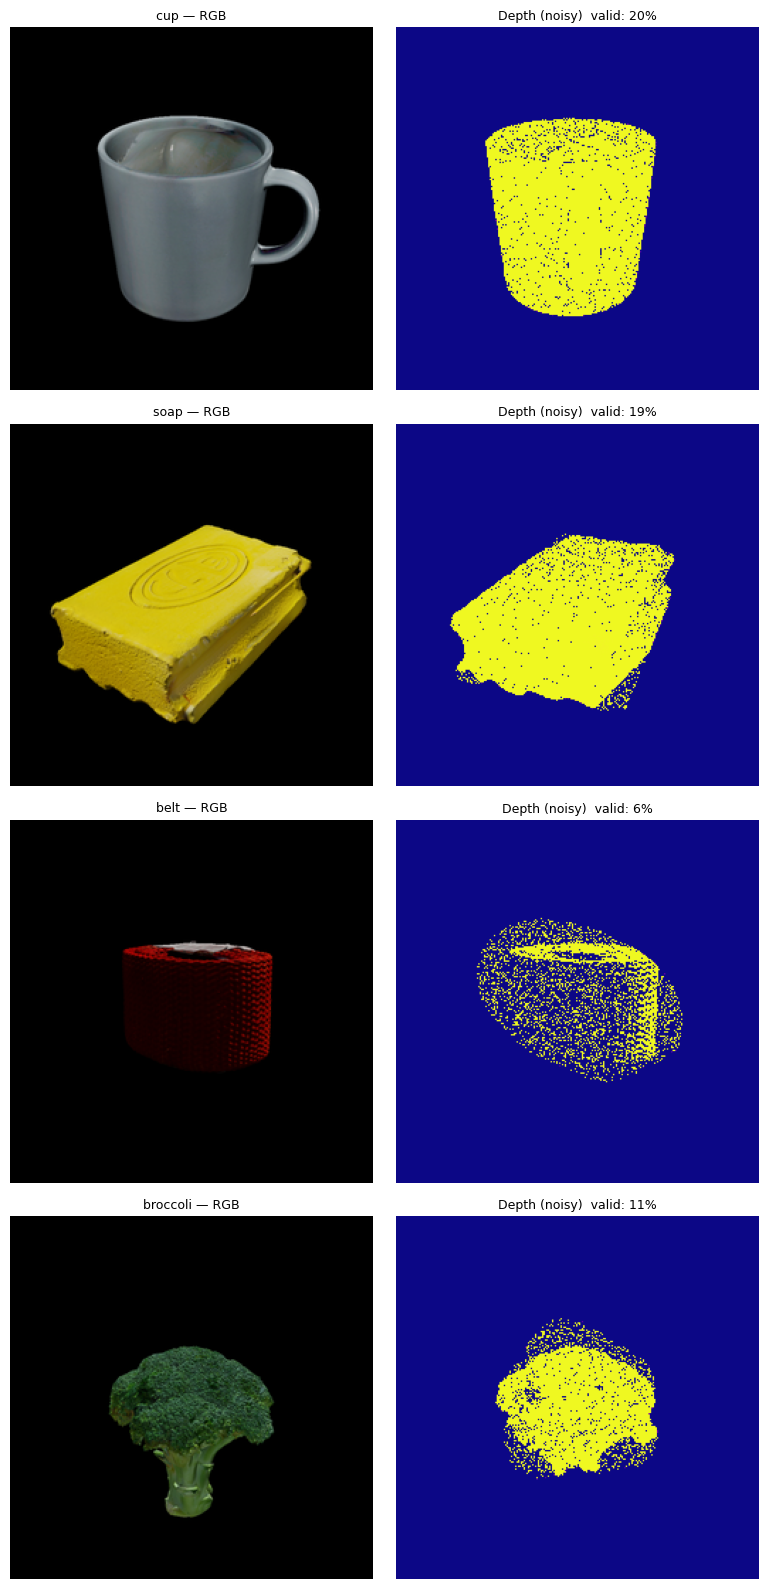

In [13]:
import random as pyrandom
import matplotlib.pyplot as plt

# Rebuild paths list from train split for spot check
spot_rgb_paths, spot_depth_paths, spot_labels = [], [], []
for cat_name in INDOOR_CATS:
    cat_dir = Path(BASE_OUT_DIR) / 'train' / cat_name
    if not cat_dir.exists():
        continue
    label_idx = cat_to_idx[cat_name]
    for rf in sorted(cat_dir.glob('*_rgb.pt')):
        df = Path(str(rf).replace('_rgb.pt', '_depth.pt'))
        if df.exists():
            spot_rgb_paths.append(rf)
            spot_depth_paths.append(df)
            spot_labels.append(label_idx)

picks = pyrandom.sample(range(len(spot_rgb_paths)), 4)
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for i, idx in enumerate(picks):
    rgb_np   = torch.load(spot_rgb_paths[idx],   weights_only=True).permute(1, 2, 0).numpy()
    depth_np = torch.load(spot_depth_paths[idx], weights_only=True).squeeze(0).numpy().astype(float)
    valid    = (depth_np > 0).mean()
    cat      = INDOOR_CATS[spot_labels[idx]]
    axes[i][0].imshow(rgb_np)
    axes[i][0].set_title(f'{cat} — RGB', fontsize=9)
    axes[i][0].axis('off')
    axes[i][1].imshow(depth_np, cmap='plasma', vmin=0, vmax=3000)
    axes[i][1].set_title(f'Depth (noisy)  valid: {valid:.0%}', fontsize=9)
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()


## 12. Package and Upload to Drive

In [14]:
local_tar = '/content/OmniObject3D_Pretrain_256.tar.gz'

print('Creating tar.gz...')
with tarfile.open(local_tar, 'w:gz') as tar:
    tar.add(BASE_OUT_DIR, arcname='sparse_omni_256')

size_gb = os.path.getsize(local_tar) / 1e9
print(f'Archive size: {size_gb:.2f} GB')

print('Uploading to Drive...')
shutil.copy(local_tar, DRIVE_OUTPUT_TAR)
print(f'Saved to: {DRIVE_OUTPUT_TAR}')

os.remove(local_tar)
shutil.rmtree(BASE_OUT_DIR)
shutil.rmtree(TMP_DIR, ignore_errors=True)
print('VM disk cleaned')
!df -h /content

Creating tar.gz...
Archive size: 9.72 GB
Uploading to Drive...
Saved to: /content/drive/MyDrive/OmniObject3D_Pretrain_256.tar.gz
VM disk cleaned
Filesystem      Size  Used Avail Use% Mounted on
overlay         226G   66G  161G  30% /
